In [1]:
# Dataset: https://huggingface.co/datasets/barilan/blog_authorship_corpus
DATA_PATH = '../data/blog_authorship_corpus.csv'

In [2]:
import pandas as pd

df = pd.read_csv(DATA_PATH)
df.head()

,id,gender,age,topic,sign,date,text
0,4162441,male,16,Student,Sagittarius,19/08/2004,DESTINY... you might not say anything but i ca...
1,4162441,male,16,Student,Sagittarius,17/08/2004,"DEAR ANGEL.. you say it or you don't, but i ca..."
2,4162441,male,16,Student,Sagittarius,16/08/2004,MAIN AUR MERI TANHAI (jagjeet singh) awara hai...
3,4162441,male,16,Student,Sagittarius,14/08/2004,mail addressrs(s) http://rediff.com http://sif...
4,4162441,male,16,Student,Sagittarius,09/08/2004,RAP- ALLRISE so stand back cause u don't notic...


In [3]:
df.shape

(681288, 7)

In [4]:
df.topic.unique()

array(['Student', 'BusinessServices', 'Education', 'indUnk', 'Technology',
       'Arts', 'Non-Profit', 'InvestmentBanking', 'Science',
       'Engineering', 'Publishing', 'Construction', 'HumanResources',
       'Communications-Media', 'Internet', 'Banking', 'Biotech',
       'Architecture', 'Advertising', 'Military', 'Chemicals', 'Fashion',
       'Law', 'Tourism', 'Museums-Libraries', 'Accounting',
       'Transportation', 'Agriculture', 'Government', 'Marketing',
       'Manufacturing', 'Religion', 'Sports-Recreation',
       'Telecommunications', 'Consulting', 'RealEstate', 'Automotive',
       'Maritime', 'LawEnforcement-Security', 'Environment'], dtype=object)

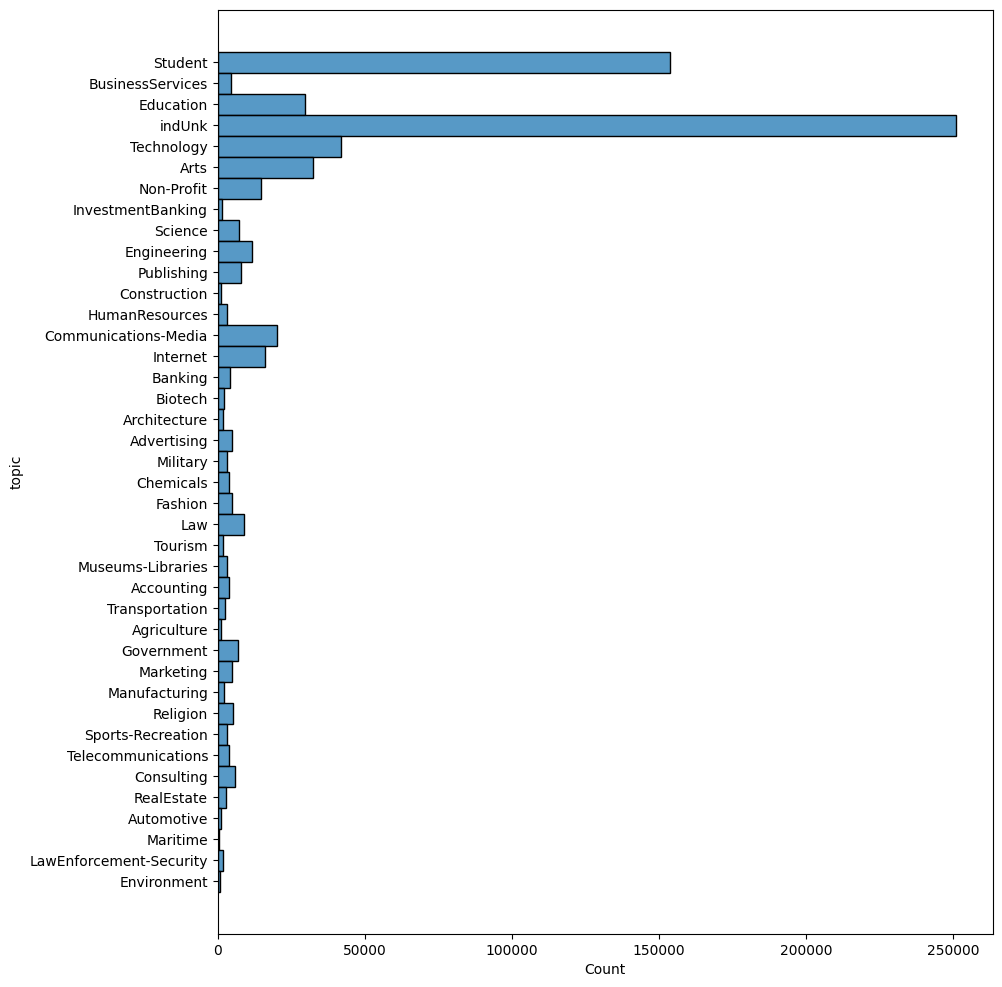

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,12))
sns.histplot(y="topic", data=df)
plt.show()

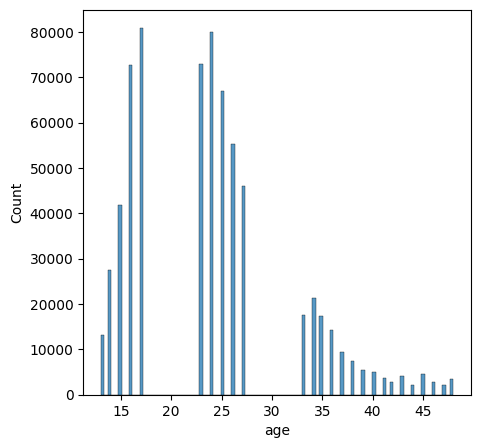

In [6]:
plt.figure(figsize=(5, 5))
sns.histplot(x="age", data=df, bins=100)
plt.show()

In [7]:
df['text'].head(20)

0     DESTINY... you might not say anything but i ca...
1     DEAR ANGEL.. you say it or you don't, but i ca...
2     MAIN AUR MERI TANHAI (jagjeet singh) awara hai...
3     mail addressrs(s) http://rediff.com http://sif...
4     RAP- ALLRISE so stand back cause u don't notic...
5     MISSING YOU BADLY. i am lonely here, searching...
6     HAZEL EYES. close your eyes and imagine a lake...
7     LET IT BE ME. a bird hibernated for a year or ...
8     It's been a long time coming, but I have made ...
9                                                   NaN
10    Yeah, I was a leeeeetle pissed off earlier thi...
11                                                  NaN
12    Happy 21st birthday to my baby brother Nick!!!...
13                                        Damn lasanga.
14    What Finding Nemo Character are You? brought t...
15    I make excellent lasagna. Just ask Ricotta Mon...
16    Oh, what a busy fucking week it has been. A cr...
17    So Jefe comes in this morning at 9:00, whe

In [8]:
df.isna().sum()

id           0
gender       0
age          0
topic        0
sign         0
date         0
text      5050
dtype: int64

In [9]:
df = df.dropna()

In [10]:
df.gender.value_counts()

gender
male      342387
female    333851
Name: count, dtype: int64

In [11]:
df['tokens'] = df.text.str.split(' ').apply(lambda s: len(s))

<Axes: xlabel='tokens', ylabel='Count'>

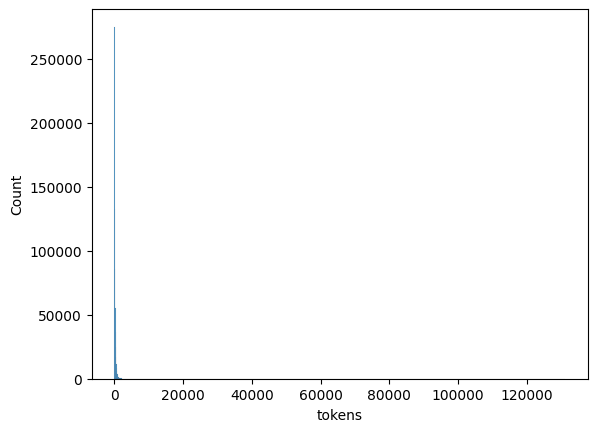

In [12]:
sns.histplot(df, x='tokens')

In [13]:
df[df.index.isin(df['tokens'].sort_values(ascending=False).head().index)]

,id,gender,age,topic,sign,date,text,tokens
114248,3414073,male,14,Communications-Media,Libra,28/05/2004,Fear And Loathing In Las Vegas A Savage Journe...,55609
229798,1174200,male,17,indUnk,Libra,15/07/2003,"Tuesday, October 28, 2003 So...Andrew did some...",56045
443428,3645055,female,14,Education,Aquarius,01/08/2004,It happened that among those worthies who were...,119297
514430,3938699,male,17,Student,Taurus,15/07/2004,Prolouge to a Mack part I - 12/8/2001 &nbsp; &...,71210
564876,3163832,female,41,indUnk,Aquarius,21/07/2004,Excerpts from the HRW report: [prologue] A Pet...,131179


In [14]:
df[df['tokens'] > 1000].shape, df[df['tokens'] <= 2].shape

((12443, 8), (10984, 8))

In [ ]:
df = df[(df['tokens'] > 2) & (df['tokens'] <= 1000)]

In [16]:
df.shape

(652811, 8)

In [17]:
df['text'].sample(100)

577547    Nah, no theme article today. No time to even u...
382528    So this Hello Blogger thing that I downloaded ...
422244                       me and my cousin Lindsay&nbsp;
65347     Well, hello everyone. My weekend was quite rel...
365624    i'm back lol. in full effect. this past month ...
                                ...                        
146448    Big Week, Big News This is a very big week for...
24380     Diet | "Another good reducing exercise consist...
555460    I got my bike back. I feel born again. Being a...
46558     I still remember vividly of the little stream ...
318008    My results in the "Which Country Are You Quiz"...
Name: text, Length: 100, dtype: object

In [18]:
df[df['text'].str.contains('--')].head(200)

,id,gender,age,topic,sign,date,text,tokens
0,4162441,male,16,Student,Sagittarius,19/08/2004,DESTINY... you might not say anything but i ca...,143
1,4162441,male,16,Student,Sagittarius,17/08/2004,"DEAR ANGEL.. you say it or you don't, but i ca...",154
2,4162441,male,16,Student,Sagittarius,16/08/2004,MAIN AUR MERI TANHAI (jagjeet singh) awara hai...,113
4,4162441,male,16,Student,Sagittarius,09/08/2004,RAP- ALLRISE so stand back cause u don't notic...,80
5,4162441,male,16,Student,Sagittarius,09/08/2004,"MISSING YOU BADLY. i am lonely here, searching...",242
...,...,...,...,...,...,...,...,...
2326,3334256,male,23,Publishing,Virgo,21/07/2004,Started day at 379...thanks Twolves Detroit +1...,14
2329,3334256,male,23,Publishing,Virgo,21/07/2004,Comment Below-->VOTE 1 thru 100,5
2330,3334256,male,23,Publishing,Virgo,21/07/2004,Started day at 244 Minnesota Timberwolves +135...,49
2332,3334256,male,23,Publishing,Virgo,21/07/2004,American League Baltimore 7 Detroit 5 -- Miggy...,502


In [19]:
# filter df text that contains weird chars
df[df['text'].str.contains(r'[^\x00-\x7F]')].head()

,id,gender,age,topic,sign,date,text,tokens
73,3489929,female,25,Student,Cancer,03/08/2004,Daily Horoscope: You Crabs can hold onto the p...,172
126,3162067,female,24,Education,Cancer,17/06/2004,"Well, I have some more excellent news! I have ...",99
160,813360,female,23,BusinessServices,Capricorn,02/12/2003,It has been a while since I last wrote almost ...,101
163,813360,female,23,BusinessServices,Capricorn,17/12/2003,Today I finally feel that someone in the world...,560
164,813360,female,23,BusinessServices,Capricorn,16/12/2003,This year it was my job to write the Christmas...,787


In [20]:
df = df[~df['text'].str.contains(r'[^\x00-\x7F]')]

In [21]:
df.head()

,id,gender,age,topic,sign,date,text,tokens
0,4162441,male,16,Student,Sagittarius,19/08/2004,DESTINY... you might not say anything but i ca...,143
1,4162441,male,16,Student,Sagittarius,17/08/2004,"DEAR ANGEL.. you say it or you don't, but i ca...",154
2,4162441,male,16,Student,Sagittarius,16/08/2004,MAIN AUR MERI TANHAI (jagjeet singh) awara hai...,113
3,4162441,male,16,Student,Sagittarius,14/08/2004,mail addressrs(s) http://rediff.com http://sif...,10
4,4162441,male,16,Student,Sagittarius,09/08/2004,RAP- ALLRISE so stand back cause u don't notic...,80


In [22]:
df['tokens'].sum()

np.int64(102275808)

In [23]:
df.shape

(612203, 8)